Модуль M3 — ОФЗ (облигации федерального займа)  
Источник: файл INTERNET_Auction_Results_rus_2026_20260507.xlsx

In [1]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO
from datetime import datetime, timedelta

In [2]:
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

In [3]:
# Разные годы: разное число колонок и то, есть ли столбец «Аукцион/ДРПА».
# Нормализация выполняется в load_ofz_year() по фактическим данным, а не по номеру года.

urls_by_year = {
    2026: "https://minfin.gov.ru/common/upload/library/2026/05/main/INTERNET_Auction_Results_rus_2026_20260507.xlsx",
    2025: "https://minfin.gov.ru/common/upload/library/2026/01/main/INTERNET_Auction_Results_rus_2025_20251231.xlsx",
    2024: "https://minfin.gov.ru/common/upload/library/2025/01/main/INTERNET_Auction_Results_rus_2024_20241231.xlsx",
    2023: "https://minfin.gov.ru/common/upload/library/2024/01/main/INTERNET_Auction_Results_rus_2023_20231231.xlsx",
    2022: "https://minfin.gov.ru/common/upload/library/2023/01/main/INTERNET_Auction_Results_rus_2022_20221222.xlsx",
    2021: "https://minfin.gov.ru/common/upload/library/2022/02/main/INTERNET_Auction_Results_rus_2021_20211223.xlsx",
    2020: "https://minfin.gov.ru/common/upload/library/2020/12/main/INTERNET_Auction_Results_rus_2020_20201223.xlsx",
    2019: "https://minfin.gov.ru/common/upload/library/2020/01/main/INTERNET_Auction_Results_rus_2019_20191218.xlsx",
    2018: "https://minfin.gov.ru/common/upload/library/2019/01/main/INTERNET_Auction_Results_rus_2018_20181226.xlsx",
    2017: "https://minfin.gov.ru/common/upload/library/2017/12/main/INTERNET_Auction_Results_rus_2017_20171227.xlsx",
    2016: "https://minfin.gov.ru/common/upload/library/2017/01/main/INTERNET_Auction_Results_rus_2016_20161230_1.xlsx"
}

In [4]:
# urls_by_year = {
#     2026: "https://minfin.gov.ru/common/upload/library/2026/05/main/INTERNET_Auction_Results_rus_2026_20260507.xlsx",
#     2025: "https://minfin.gov.ru/common/upload/library/2026/01/main/INTERNET_Auction_Results_rus_2025_20251231.xlsx",
#     2024: "https://minfin.gov.ru/common/upload/library/2025/01/main/INTERNET_Auction_Results_rus_2024_20241231.xlsx",
#     2023: "https://minfin.gov.ru/common/upload/library/2024/01/main/INTERNET_Auction_Results_rus_2023_20231231.xlsx",
#     2022: "https://minfin.gov.ru/common/upload/library/2023/01/main/INTERNET_Auction_Results_rus_2022_20221222.xlsx",
#     2021: "https://minfin.gov.ru/common/upload/library/2022/02/main/INTERNET_Auction_Results_rus_2021_20211223.xlsx",
#     2020: "https://minfin.gov.ru/common/upload/library/2020/12/main/INTERNET_Auction_Results_rus_2020_20201223.xlsx",
#     2019: "https://minfin.gov.ru/common/upload/library/2020/01/main/INTERNET_Auction_Results_rus_2019_20191218.xlsx",
#     2018: "https://minfin.gov.ru/common/upload/library/2019/01/main/INTERNET_Auction_Results_rus_2018_20181226.xlsx",
#     2017: "https://minfin.gov.ru/common/upload/library/2017/12/main/INTERNET_Auction_Results_rus_2017_20171227.xlsx",
#     2016: "https://minfin.gov.ru/common/upload/library/2017/01/main/INTERNET_Auction_Results_rus_2016_20161230_1.xlsx"
# }

In [5]:
COLS_WITH_FORMAT = [
    'date', 'format', 'code', 'type', 'maturity_date', 'days_to_maturity',
    'volume_offer', 'price_cutoff', 'price_avg', 'yield_cutoff', 'yield_avg',
    'volume_demand', 'volume_placement', 'volume_revenue', 'satisfaction_coef',
]

COLS_NO_FORMAT_14 = [
    'date', 'code', 'type', 'maturity_date', 'days_to_maturity',
    'volume_offer', 'price_cutoff', 'price_avg', 'yield_cutoff', 'yield_avg',
    'volume_demand', 'volume_placement', 'volume_revenue', 'satisfaction_coef',
]

COLS_NO_FORMAT_13 = COLS_NO_FORMAT_14[:13]


def _second_col_is_format(df):
    """True, если 2-й столбец — тип размещения (Аукцион/ДРПА), а не ISIN."""
    if df.shape[1] < 2:
        return False
    s = df.iloc[:, 1].dropna().astype(str).str.strip()
    if len(s) == 0:
        return False
    return bool((s.isin(['Аукцион', 'ДРПА'])).mean() >= 0.25)


def normalize_minfin_ofz_dataframe(df, year):
    """Приводит сырые строки Minfin (после skiprows=8) к единой схеме COLS_WITH_FORMAT."""
    n = df.shape[1]
    has_fmt = _second_col_is_format(df)

    if has_fmt and n == 15:
        df = df.copy()
        df.columns = COLS_WITH_FORMAT
        return df

    if not has_fmt and n == 14:
        df = df.copy()
        df.columns = COLS_NO_FORMAT_14
        df.insert(1, 'format', 'Аукцион')
        return df

    if not has_fmt and n == 15:
        # 2016–2018: после выручки идут (спрос/предл.) и (разм./предл.) — лишние для ТЗ
        df = df.iloc[:, :13].copy()
        df.columns = COLS_NO_FORMAT_13
        df.insert(1, 'format', 'Аукцион')
        df['satisfaction_coef'] = np.nan
        return df

    raise ValueError(f'Год {year}: неожиданная таблица (ncols={n}, format_col={has_fmt})')


def load_ofz_year(year, url):
    try:
        response = requests.get(url, headers=headers, timeout=30)
        if response.status_code == 200:
            df_year = pd.read_excel(BytesIO(response.content), skiprows=8)
            df_year = normalize_minfin_ofz_dataframe(df_year, year)
            print(f"✅ {year}: загружен, {len(df_year)} строк, колонок: {len(df_year.columns)}")
            return df_year
        print(f"❌ {year}: статус {response.status_code}")
        return None
    except Exception as e:
        print(f"❌ {year}: ошибка {e}")
        return None

In [6]:
# def load_ofz_year(year, url):
#     try:
#         response = requests.get(url, headers=headers, timeout=30)
#         if response.status_code == 200:
#             df_year = pd.read_excel(BytesIO(response.content), skiprows=8)
#             print(f"✅ {year}: загружен, {len(df_year)} строк")
#             return df_year
#         else:
#             print(f"❌ {year}: статус {response.status_code}")
#             return None
#     except Exception as e:
#         print(f"❌ {year}: ошибка {e}")
#         return None

In [7]:
all_dfs = []
for year, url in urls_by_year.items():
    df_year = load_ofz_year(year, url)
    if df_year is not None:
        all_dfs.append(df_year)

print(f"\nЗагружено файлов: {len(all_dfs)}")

✅ 2026: загружен, 48 строк, колонок: 15
✅ 2025: загружен, 144 строк, колонок: 15
✅ 2024: загружен, 106 строк, колонок: 15
✅ 2023: загружен, 97 строк, колонок: 15
✅ 2022: загружен, 39 строк, колонок: 15
✅ 2021: загружен, 85 строк, колонок: 15
✅ 2020: загружен, 89 строк, колонок: 15
✅ 2019: загружен, 86 строк, колонок: 15
✅ 2018: загружен, 83 строк, колонок: 15
✅ 2017: загружен, 100 строк, колонок: 15
✅ 2016: загружен, 89 строк, колонок: 15

Загружено файлов: 11


In [8]:
if all_dfs:
    df_all = pd.concat(all_dfs, ignore_index=True)
    print(f"Объединённый датафрейм: {df_all.shape}")
else:
    # Если ничего не загрузилось — выходим с ошибкой
    raise Exception("Не загружен ни один файл")

df_all.head()

Объединённый датафрейм: (966, 15)


,date,format,code,type,maturity_date,days_to_maturity,volume_offer,price_cutoff,price_avg,yield_cutoff,yield_avg,volume_demand,volume_placement,volume_revenue,satisfaction_coef
0,2026-01-14 00:00:00,Аукцион,26253RMFS,ОФЗ-ПД,2038-10-06,4648.0,674231.070,91.4983,91.52,14.99,14.99,44396.336,13460.899,12726.87558,0.303198
1,2026-01-14 00:00:00,Аукцион,26225RMFS,ОФЗ-ПД,2034-05-10,3038.0,43860.598,66.3191,66.3382,14.8,14.8,25897.05,13651.899,9210.964504,0.52716
2,2026-01-21 00:00:00,Аукцион,26228RMFS,ОФЗ-ПД,2030-04-10,1540.0,100000.000,79.8112,79.8785,14.66,14.64,56940.644,14949.844,12251.918207,0.262551
3,2026-01-21 00:00:00,Аукцион,26230RMFS,ОФЗ-ПД,2039-03-16,4802.0,89175.661,61.6841,61.7155,14.71,14.71,74557.805,50860.676,32601.459336,0.682164
4,2026-01-21 00:00:00,ДРПА,26230RMFS,ОФЗ-ПД,2039-03-16,4802.0,12823.202,61.7155,61.7155,14.71,14.71,-,9145.295,5862.088369,-


In [9]:
# Единая схема колонок уже задана в load_ofz_year()

df_all['date'] = pd.to_datetime(df_all['date'], errors='coerce')
df_all['maturity_date'] = pd.to_datetime(df_all['maturity_date'], errors='coerce')

for col in [
    'days_to_maturity', 'volume_offer', 'volume_demand', 'volume_placement',
    'price_cutoff', 'price_avg', 'yield_cutoff', 'yield_avg',
    'volume_revenue', 'satisfaction_coef',
]:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# Коэфф. удовлетворения заявок, если отсутствовал в файле 2016–2018
m = df_all['satisfaction_coef'].isna() & (df_all['volume_demand'] > 0)
df_all.loc[m, 'satisfaction_coef'] = (
    df_all.loc[m, 'volume_placement'] / df_all.loc[m, 'volume_demand']
)

df_all = df_all[df_all['format'] == 'Аукцион'].copy()
df_all = df_all.sort_values('date').reset_index(drop=True)

# Объёмы в исходниках — млн руб.; для отчёта — млрд руб.
for c, newc in [
    ('volume_offer', 'volume_offer_bln'),
    ('volume_demand', 'volume_demand_bln'),
    ('volume_placement', 'volume_placement_bln'),
]:
    df_all[newc] = df_all[c] / 1000.0

print(f"После очистки: {df_all.shape}")
print(f"Диапазон дат: {df_all['date'].min()} — {df_all['date'].max()}")
df_all.head()

После очистки: (882, 18)
Диапазон дат: 2016-01-13 00:00:00 — 2026-05-06 00:00:00


,date,format,code,type,maturity_date,days_to_maturity,volume_offer,price_cutoff,price_avg,yield_cutoff,yield_avg,volume_demand,volume_placement,volume_revenue,satisfaction_coef,volume_offer_bln,volume_demand_bln,volume_placement_bln
0,2016-01-13,Аукцион,24018RMFS,ОФЗ-ПК,2017-12-27,714.0,10000.0,101.5500,101.6562,11.38,11.31,16517.110,9522.916,9724.436969,0.576549,10.0,16.517110,9.522916
1,2016-01-13,Аукцион,26214RMFS,ОФЗ-ПД,2020-05-27,1596.0,7800.0,86.3555,86.5404,10.62,10.56,17460.237,7800.000,6807.560875,0.446729,7.8,17.460237,7.800000
2,2016-01-20,Аукцион,29006RMFS,ОФЗ-ПК,2025-01-29,3297.0,12000.0,102.5800,102.6350,14.45,14.44,24993.603,12000.000,13082.640000,0.480123,12.0,24.993603,12.000000
3,2016-01-20,Аукцион,26207RMFS,ОФЗ-ПД,2027-02-03,4032.0,8000.0,84.8110,85.0496,10.78,10.74,14818.433,8000.000,7079.088429,0.539868,8.0,14.818433,8.000000
4,2016-01-27,Аукцион,29006RMFS,ОФЗ-ПК,2025-01-29,3290.0,16000.0,102.8000,102.8649,14.41,14.39,26928.290,11189.956,12256.343421,0.415546,16.0,26.928290,11.189956


In [10]:
# Базовые поля Minfin + производные (млрд руб.)
missing = set(COLS_WITH_FORMAT) - set(df_all.columns)
assert not missing, missing
print('Базовых колонок Minfin OK; всего колонок:', len(df_all.columns))

Базовых колонок Minfin OK; всего колонок: 18


In [11]:
# Фильтруем аномальные значения объёмов
# ОФЗ — это миллиарды рублей, но в данных встречаются огромные значения из-за ошибок
# Удаляем строки, где volume_offer или volume_demand явно некорректны
df_all_clean = df_all.copy()

# Удаляем строки с отрицательными объёмами
df_all_clean = df_all_clean[(df_all_clean['volume_offer'] >= 0) & (df_all_clean['volume_demand'] >= 0)]

# Удаляем строки, где volume_offer = 0 (иначе cover_ratio = inf)
df_all_clean = df_all_clean[df_all_clean['volume_offer'] > 0]

# Удаляем явные выбросы: cover_ratio больше 100 скорее всего ошибка
# Но сначала посчитаем cover_ratio
df_all_clean['cover_ratio_temp'] = df_all_clean['volume_demand'] / df_all_clean['volume_offer']
df_all_clean = df_all_clean[df_all_clean['cover_ratio_temp'] <= 100]

# Удаляем временную колонку
df_all_clean = df_all_clean.drop(columns=['cover_ratio_temp'])

print(f"После фильтрации выбросов: {df_all_clean.shape}")
print(f"Максимальный cover_ratio: { (df_all_clean['volume_demand'] / df_all_clean['volume_offer']).max() }")

После фильтрации выбросов: (868, 18)
Максимальный cover_ratio: 11.3399178


In [12]:
# Используем очищенный датафрейм вместо df_all
df_all = df_all_clean.copy()

# Cover ratio = спрос / предложение
df_all['cover_ratio'] = np.where(
    df_all['volume_offer'] > 0,
    df_all['volume_demand'] / df_all['volume_offer'],
    np.nan
)

# Флаги по ТЗ
df_all['flag_nedospros'] = (df_all['cover_ratio'] < 1.2).astype(int)
df_all['flag_perespros'] = (df_all['cover_ratio'] > 2.0).astype(int)

# Отклонение доходности от кусочно-линейной «кривой» по сроку (в тот же день аукциона)
def yield_spread_vs_nearby_curve(df):
    out = pd.Series(np.nan, index=df.index)

    def _interp(d, y, i, n):
        eps = 1e-9
        if i == 0:
            den = (d[2] - d[1])
            return y[1] + (y[2] - y[1]) * (d[0] - d[1]) / (den if abs(den) > eps else eps)
        if i == n - 1:
            den = (d[n - 2] - d[n - 3])
            return y[n - 3] + (y[n - 2] - y[n - 3]) * (d[n - 1] - d[n - 3]) / (den if abs(den) > eps else eps)
        den = (d[i + 1] - d[i - 1])
        return y[i - 1] + (y[i + 1] - y[i - 1]) * (d[i] - d[i - 1]) / (den if abs(den) > eps else eps)

    def block_spread(g):
        g = g.sort_values('days_to_maturity')
        d = g['days_to_maturity'].to_numpy(dtype=float)
        y = g['yield_avg'].to_numpy(dtype=float)
        n = len(g)
        sp = np.zeros(n)
        if n == 1:
            sp[:] = 0.0
        elif n == 2:
            sp[0] = y[0] - y[1]
            sp[1] = y[1] - y[0]
        else:
            for i in range(n):
                yhat = _interp(d, y, i, n)
                sp[i] = y[i] - yhat
        return pd.Series(sp, index=g.index)

    for _, g in df.groupby('date'):
        out.loc[g.index] = block_spread(g)
    return out


df_all['yield_spread'] = yield_spread_vs_nearby_curve(df_all)

# Доп. флаг: аукцион не состоялся
df_all['flag_failed'] = ((df_all['volume_placement'] == 0) | (df_all['volume_placement'].isna())).astype(int)

df_all = df_all.sort_values('date').reset_index(drop=True)

# Итоговая таблица по заданию (по каждому выпуску / строке аукциона)
df_auction_table = df_all[[
    'date', 'code', 'type',
    'volume_offer_bln', 'volume_demand_bln', 'volume_placement_bln',
    'cover_ratio', 'yield_avg', 'yield_spread',
    'flag_nedospros', 'flag_perespros',
]].rename(columns={
    'date': 'Дата аукциона',
    'code': 'Выпуск (серия)',
    'type': 'Тип',
    'volume_offer_bln': 'Объём предложения (млрд руб.)',
    'volume_demand_bln': 'Объём спроса (млрд руб.)',
    'volume_placement_bln': 'Объём размещения (млрд руб.)',
    'cover_ratio': 'Cover ratio',
    'yield_avg': 'Средневзвешенная доходность, %',
    'yield_spread': 'Отклонение от кривой (по соседним срокам), п.п.',
    'flag_nedospros': 'Недоспрос (<1.2)',
    'flag_perespros': 'Переспрос (>2.0)',
})

print(f"Диапазон дат: {df_all['date'].min()} — {df_all['date'].max()}")
print(f"Всего аукционов (строк выпусков): {len(df_all)}")
print(f"Недоспрос (<1.2): {df_all['flag_nedospros'].mean():.1%}")
print(f"Переспрос (>2.0): {df_all['flag_perespros'].mean():.1%}")
print(f"Максимальный cover_ratio после очистки: {df_all['cover_ratio'].max()}")
df_auction_table.head()

Диапазон дат: 2016-01-13 00:00:00 — 2026-05-06 00:00:00
Всего аукционов (строк выпусков): 868
Недоспрос (<1.2): 54.7%
Переспрос (>2.0): 26.3%
Максимальный cover_ratio после очистки: 11.3399178


,Дата аукциона,Выпуск (серия),Тип,Объём предложения (млрд руб.),Объём спроса (млрд руб.),Объём размещения (млрд руб.),Cover ratio,"Средневзвешенная доходность, %","Отклонение от кривой (по соседним срокам), п.п.",Недоспрос (<1.2),Переспрос (>2.0)
0,2016-01-13,24018RMFS,ОФЗ-ПК,10.0,16.517110,9.522916,1.651711,11.31,0.75,0,0
1,2016-01-13,26214RMFS,ОФЗ-ПД,7.8,17.460237,7.800000,2.238492,10.56,-0.75,0,1
2,2016-01-20,29006RMFS,ОФЗ-ПК,12.0,24.993603,12.000000,2.082800,14.44,3.70,0,1
3,2016-01-20,26207RMFS,ОФЗ-ПД,8.0,14.818433,8.000000,1.852304,10.74,-3.70,0,0
4,2016-01-27,29006RMFS,ОФЗ-ПК,16.0,26.928290,11.189956,1.683018,14.39,0.41,0,0


### EDA: аукционы по выпускам (`df_all`)

После очистки объёмов и расчёта `cover_ratio`, флагов и `yield_spread`: распределения и структура по типам бумаг.

=== Уровень выпуска (после фильтров) ===
(868, 23) | даты: 2016-01-13 00:00:00 — 2026-05-06 00:00:00

Пропуски % по ключевым числовым полям:
volume_offer         0.00
volume_demand        0.00
volume_placement     0.00
cover_ratio          0.00
yield_avg           12.21
yield_cutoff        12.21
yield_spread        19.70
days_to_maturity     0.46
dtype: float64


,count,mean,std,min,25%,50%,75%,max
volume_offer,868.0,196964.553260,400716.387791,3948.259806,15093.450000,50000.00000,322527.679750,9.766180e+06
volume_demand,868.0,93125.615406,272902.185396,188.790494,25186.870250,44656.84050,81599.943250,4.404693e+06
volume_placement,868.0,45669.332347,130371.487649,0.000000,10000.000000,19999.99400,40628.652250,2.082619e+06
cover_ratio,868.0,1.316028,1.225923,0.001037,0.284149,0.97297,2.080331,1.133992e+01
yield_avg,762.0,9.353071,3.771649,0.000000,7.190000,8.36000,11.777500,1.842000e+01
yield_cutoff,762.0,9.367493,3.772592,0.000000,7.192500,8.37000,11.782500,1.843000e+01
yield_spread,697.0,1.367640,14.249953,-90.425143,-0.330000,0.00000,0.400000,1.458556e+02
days_to_maturity,864.0,3435.440972,1542.648764,476.000000,2091.250000,3458.00000,4690.000000,7.266000e+03



Типы бумаг:


,count
type,
ОФЗ-ПД,655
ОФЗ-ПК,131
ОФЗ-ИН,78


flag_nedospros: 54.72% дней-строк с флагом=1
flag_perespros: 26.27% дней-строк с флагом=1
flag_failed: 4.38% дней-строк с флагом=1


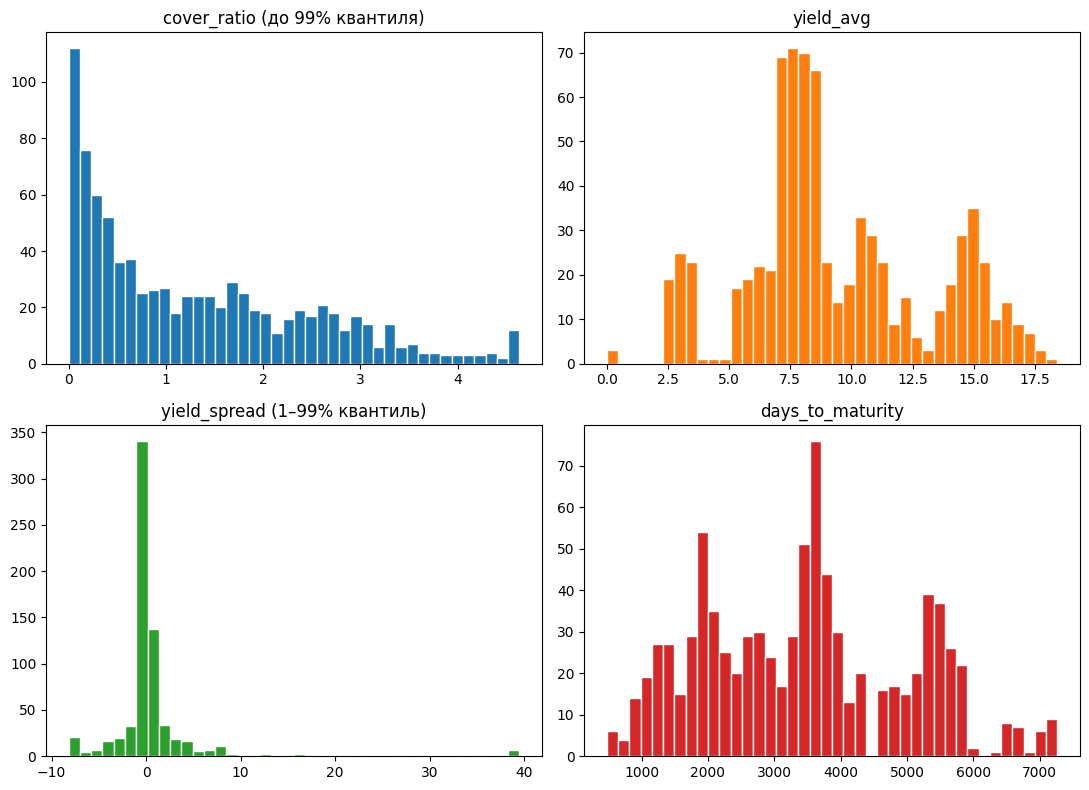


Число строк по годам (дата аукциона):
y
2016.0    87
2017.0    98
2018.0    81
2019.0    84
2020.0    87
2021.0    82
2022.0    37
2023.0    95
2024.0    84
2025.0    95
2026.0    34
dtype: int64


In [13]:
import matplotlib.pyplot as plt

print("=== Уровень выпуска (после фильтров) ===")
print(df_all.shape, "| даты:", df_all["date"].min(), "—", df_all["date"].max())

eda_num = [
    "volume_offer",
    "volume_demand",
    "volume_placement",
    "cover_ratio",
    "yield_avg",
    "yield_cutoff",
    "yield_spread",
    "days_to_maturity",
]
eda_num = [c for c in eda_num if c in df_all.columns]
print("\nПропуски % по ключевым числовым полям:")
print((df_all[eda_num].isna().mean() * 100).round(2))
display(df_all[eda_num].describe().T)

if "type" in df_all.columns:
    print("\nТипы бумаг:")
    display(df_all["type"].value_counts())

for f in ["flag_nedospros", "flag_perespros", "flag_failed"]:
    if f in df_all.columns:
        print(f"{f}: {df_all[f].mean():.2%} дней-строк с флагом=1")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
ax = axes.ravel()
if "cover_ratio" in df_all.columns:
    cr = df_all["cover_ratio"].clip(upper=df_all["cover_ratio"].quantile(0.99))
    ax[0].hist(cr, bins=40, color="C0", edgecolor="white")
    ax[0].set_title("cover_ratio (до 99% квантиля)")
if "yield_avg" in df_all.columns:
    ax[1].hist(df_all["yield_avg"].dropna(), bins=40, color="C1", edgecolor="white")
    ax[1].set_title("yield_avg")
if "yield_spread" in df_all.columns:
    ys = df_all["yield_spread"].dropna()
    ysc = ys.clip(ys.quantile(0.01), ys.quantile(0.99))
    ax[2].hist(ysc, bins=40, color="C2", edgecolor="white")
    ax[2].set_title("yield_spread (1–99% квантиль)")
if "days_to_maturity" in df_all.columns:
    ax[3].hist(df_all["days_to_maturity"].dropna(), bins=40, color="C3", edgecolor="white")
    ax[3].set_title("days_to_maturity")
plt.tight_layout()
plt.show()

print("\nЧисло строк по годам (дата аукциона):")
print(df_all.assign(y=df_all["date"].dt.year).groupby("y").size())

**Интерпретация: уровень выпуска (аукционы `df_all`) (M3)**

**Cover_ratio** (усечённый по 99-му перцентилю) показывает типичную плотность спроса к предложению по выпускам: узкий пик около 1–2 означает стабильные размещения, тяжёлый правый хвост — частые эпизоды переспроса. **yield_avg** задаёт распределение средневзвешенной доходности размещённого объёма; сдвиг всей гистограммы во времени (по годам в таблице ниже) соответствует изменению уровня процентных ставок на рынке ОФЗ. **yield_spread** в усечённых квантилях отражает внутридневной/внутриаукционный разброс относительно ожиданий по кривой — широкое распределение ⇒ более неоднородные размещения. **days_to_maturity** показывает, на каких горизонтах погашения в основном проходят аукционы в выборке (короткий или длинный «хвост» бумаг). Доли бинарных флагов недоспроса, переспроса и срыва дополняют картину редких режимов, которые на гистограмме могут быть не так заметны.

In [14]:
def mad_normalize_series(series, window_days=756):
    """
    MAD-нормализация за скользящее окно (3 года ~ 756 дней)
    Возвращает (x - median) / MAD
    """
    normalized = series.copy()
    for i in range(len(series)):
        start = max(0, i - window_days)
        window_data = series.iloc[start:i].dropna()

        if len(window_data) < 30:
            normalized.iloc[i] = 0.0
            continue

        median = window_data.median()
        mad = (window_data - median).abs().median()

        if mad == 0:
            normalized.iloc[i] = 0.0
        else:
            normalized.iloc[i] = (series.iloc[i] - median) / mad

    return normalized

In [15]:
# # Добавляем MAD-нормализованные сигналы
# df_all['mad_score_cover'] = mad_normalize_series(df_all['cover_ratio'])
# df_all['mad_score_yield'] = mad_normalize_series(df_all['yield_avg'])
# df_all['mad_score_yield_spread'] = mad_normalize_series(df_all['yield_spread'])

# print("MAD-сигналы добавлены")
# df_all[['date', 'cover_ratio', 'mad_score_cover', 'yield_spread', 'mad_score_yield_spread']].head(10)

In [16]:
# Агрегация по дням: суммируем объёмы, cover = Σспрос / Σпредложение, доходность — по объёму размещения

rows = []
for dt, g in df_all.groupby('date'):
    vo = g['volume_offer'].sum()
    vd = g['volume_demand'].sum()
    vp = g['volume_placement'].sum()
    w = g['volume_placement'].fillna(0).clip(lower=0)
    if w.sum() > 0:
        ybar = float(np.average(g['yield_avg'], weights=w))
    else:
        ybar = float(g['yield_avg'].mean())
    ys = float(g['yield_spread'].mean())
    cr = vd / vo if vo > 0 else np.nan
    rows.append({
        'date': dt,
        'volume_offer': vo,
        'volume_demand': vd,
        'volume_placement': vp,
        'yield_avg': ybar,
        'yield_spread': ys,
        'cover_ratio': cr,
        'flag_nedospros': int((g['cover_ratio'] < 1.2).any()),
        'flag_perespros': int((g['cover_ratio'] > 2.0).any()),
        'flag_failed': int(g['flag_failed'].max()),
    })

df_grouped = pd.DataFrame(rows)

print(f"После агрегации по дням: {len(df_grouped)} уникальных дат с аукционами")

flag_cols = ['flag_nedospros', 'flag_perespros', 'flag_failed']

df_daily = df_grouped.set_index('date').resample('D').ffill()

for flag in flag_cols:
    df_daily[flag] = df_daily[flag].fillna(0).astype(int)

df_daily = df_daily.reset_index()

print(f"Ежедневных записей: {len(df_daily)}")
print(f"Диапазон дат: {df_daily['date'].min()} — {df_daily['date'].max()}")
print(f"Дней с недоспросом: {df_daily['flag_nedospros'].sum()}")
df_daily[['date', 'cover_ratio', 'flag_nedospros']].head(10)

После агрегации по дням: 448 уникальных дат с аукционами
Ежедневных записей: 3767
Диапазон дат: 2016-01-13 00:00:00 — 2026-05-06 00:00:00
Дней с недоспросом: 2486


,date,cover_ratio,flag_nedospros
0,2016-01-13,1.908840,0
1,2016-01-14,1.908840,0
2,2016-01-15,1.908840,0
3,2016-01-16,1.908840,0
4,2016-01-17,1.908840,0
5,2016-01-18,1.908840,0
6,2016-01-19,1.908840,0
7,2016-01-20,1.990602,0
8,2016-01-21,1.990602,0
9,2016-01-22,1.990602,0


In [17]:
# Применяем MAD-нормализацию к ежедневному ряду (после ресемплинга)
# Но только для данных начиная с 2021 года (до этого окно слишком мало)
df_daily_full = df_daily.copy()

# Создаём копию для расчёта MAD только с 2021 года
df_daily_recent = df_daily[df_daily['date'] >= '2021-01-01'].copy()

# Обрезаем выбросы cover_ratio до разумного предела (10)
# Это предотвращает появление огромных MAD-значений
cover_ratio_clipped = df_daily_recent['cover_ratio'].clip(upper=10)

# Нормализуем обрезанный ряд
df_daily_recent['mad_score_cover'] = mad_normalize_series(cover_ratio_clipped)
df_daily_recent['mad_score_yield'] = mad_normalize_series(df_daily_recent['yield_avg'])
df_daily_recent['mad_score_yield_spread'] = mad_normalize_series(df_daily_recent['yield_spread'])

# Объединяем обратно: для старых данных ставим 0
df_daily = df_daily_full.copy()
df_daily.loc[df_daily['date'] >= '2021-01-01', 'mad_score_cover'] = df_daily_recent['mad_score_cover'].values
df_daily.loc[df_daily['date'] >= '2021-01-01', 'mad_score_yield'] = df_daily_recent['mad_score_yield'].values
df_daily.loc[df_daily['date'] >= '2021-01-01', 'mad_score_yield_spread'] = df_daily_recent['mad_score_yield_spread'].values

# Для старых дат заполняем нулями
df_daily['mad_score_cover'] = df_daily['mad_score_cover'].fillna(0)
df_daily['mad_score_yield'] = df_daily['mad_score_yield'].fillna(0)
df_daily['mad_score_yield_spread'] = df_daily['mad_score_yield_spread'].fillna(0)

print("MAD-сигналы добавлены (с 2021 года)")
df_daily[['date', 'cover_ratio', 'mad_score_cover', 'yield_spread', 'mad_score_yield_spread']].head(10)

MAD-сигналы добавлены (с 2021 года)


,date,cover_ratio,mad_score_cover,yield_spread,mad_score_yield_spread
0,2016-01-13,1.908840,0.0,0.0,0.0
1,2016-01-14,1.908840,0.0,0.0,0.0
2,2016-01-15,1.908840,0.0,0.0,0.0
3,2016-01-16,1.908840,0.0,0.0,0.0
4,2016-01-17,1.908840,0.0,0.0,0.0
5,2016-01-18,1.908840,0.0,0.0,0.0
6,2016-01-19,1.908840,0.0,0.0,0.0
7,2016-01-20,1.990602,0.0,0.0,0.0
8,2016-01-21,1.990602,0.0,0.0,0.0
9,2016-01-22,1.990602,0.0,0.0,0.0


In [18]:
# Финальный датафрейм БЕЗ колонки 'code' (она не нужна для LSI)
df_m3_final = df_daily[[
    'date',                     # Дата
    'volume_offer',             # Объём предложения
    'volume_demand',            # Объём спроса
    'volume_placement',         # Объём размещения
    'cover_ratio',              # Cover ratio
    'yield_avg',                # Средневзвешенная доходность
    'yield_spread',             # Отклонение доходности от кривой
    'flag_nedospros',           # Флаг недоспрос (<1.2)
    'flag_perespros',           # Флаг переспрос (>2.0)
    'mad_score_cover',          # MAD-нормализованный cover
    'mad_score_yield',          # MAD-нормализованная доходность
    'mad_score_yield_spread'    # MAD-нормализованный спред доходности
]].copy()

print(f"Финальный датафрейм M3: {df_m3_final.shape}")
df_m3_final.head()

Финальный датафрейм M3: (3767, 12)


,date,volume_offer,volume_demand,volume_placement,cover_ratio,yield_avg,yield_spread,flag_nedospros,flag_perespros,mad_score_cover,mad_score_yield,mad_score_yield_spread
0,2016-01-13,17800.0,33977.347,17322.916,1.90884,10.972297,0.0,0,1,0.0,0.0,0.0
1,2016-01-14,17800.0,33977.347,17322.916,1.90884,10.972297,0.0,0,1,0.0,0.0,0.0
2,2016-01-15,17800.0,33977.347,17322.916,1.90884,10.972297,0.0,0,1,0.0,0.0,0.0
3,2016-01-16,17800.0,33977.347,17322.916,1.90884,10.972297,0.0,0,1,0.0,0.0,0.0
4,2016-01-17,17800.0,33977.347,17322.916,1.90884,10.972297,0.0,0,1,0.0,0.0,0.0


### EDA: дневной ряд сигналов (`df_m3_final`)

Ежедневные агрегаты после ресемплинга: покрытие, доходность, спред по кривой и MAD-сигналы до бэктеста.

(3767, 9)
2016-01-13 00:00:00 — 2026-05-06 00:00:00


,count,mean,std,min,25%,50%,75%,max
volume_offer,3767.0,348368.621512,363089.591530,5000.000000,30000.000000,251319.104000,571501.658000,2.442359e+06
volume_demand,3767.0,139518.150425,214057.133347,2704.247494,55451.237207,87799.358835,158793.856000,3.443141e+06
volume_placement,3767.0,68954.678915,126090.057617,0.000000,21308.564462,36469.317308,76070.437000,1.855798e+06
cover_ratio,3767.0,1.200773,1.171558,0.011259,0.218370,0.708443,2.075407,7.587518e+00
yield_avg,3066.0,9.350299,3.337574,1.315173,7.277623,8.368537,10.680331,1.803008e+01
yield_spread,3186.0,0.724772,5.828185,-30.316085,0.000000,0.000000,0.000000,4.878263e+01
flag_nedospros,3767.0,0.659942,0.473791,0.000000,0.000000,1.000000,1.000000,1.000000e+00
flag_perespros,3767.0,0.356783,0.479113,0.000000,0.000000,0.000000,1.000000,1.000000e+00
mad_score_cover,3767.0,0.971153,4.865320,-2.927264,-0.017380,0.000000,0.041406,4.478579e+01
mad_score_yield,3767.0,0.718859,4.022029,-22.500000,0.000000,0.000000,0.713457,8.459925e+01



Дней недоспрос / переспрос: 2486 / 1344 из 3767


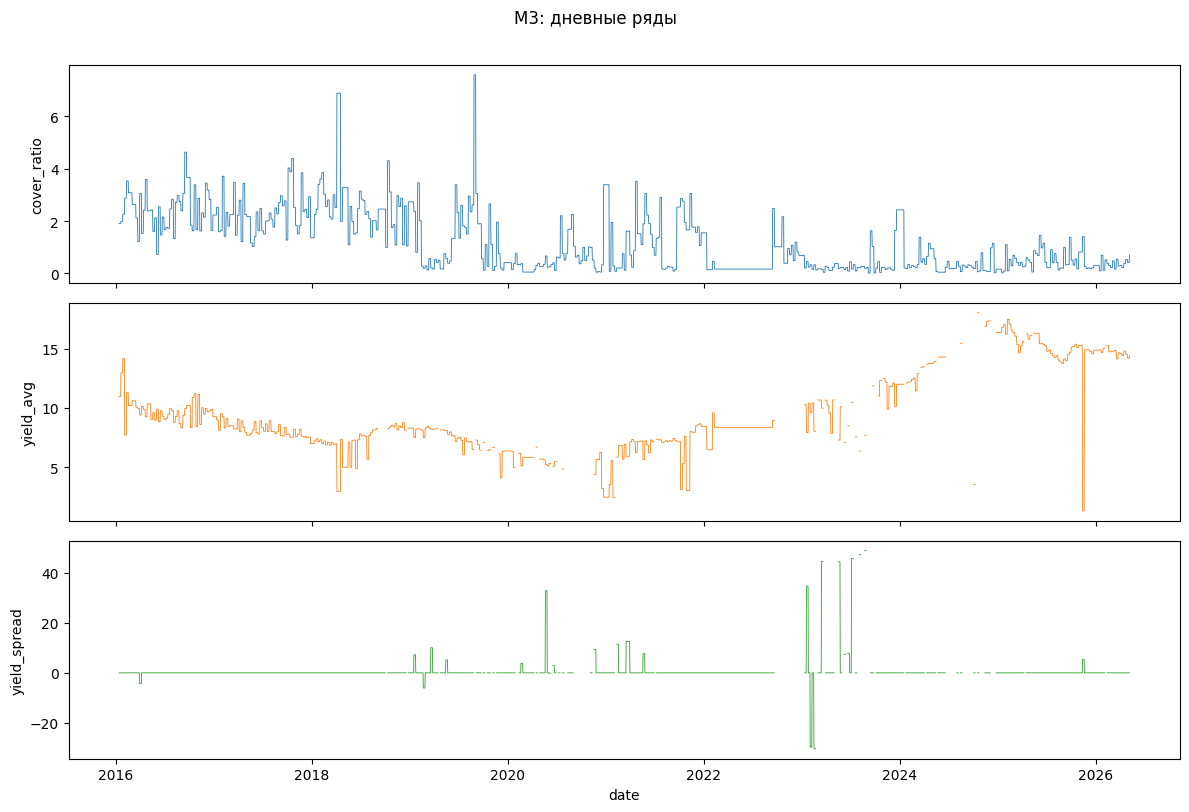

In [19]:
cols = [
    "date",
    "cover_ratio",
    "yield_avg",
    "yield_spread",
    "flag_nedospros",
    "flag_perespros",
    "mad_score_cover",
    "mad_score_yield",
    "mad_score_yield_spread",
]
cols = [c for c in cols if c in df_m3_final.columns]
print(df_m3_final[cols].shape)
print(df_m3_final["date"].min(), "—", df_m3_final["date"].max())

num = df_m3_final.select_dtypes(include=[np.number]).columns
display(df_m3_final[num].describe().T)

if {"flag_nedospros", "flag_perespros"}.issubset(df_m3_final.columns):
    print(
        "\nДней недоспрос / переспрос:",
        int(df_m3_final["flag_nedospros"].sum()),
        "/",
        int(df_m3_final["flag_perespros"].sum()),
        "из",
        len(df_m3_final),
    )

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
if "cover_ratio" in df_m3_final.columns:
    axes[0].plot(df_m3_final["date"], df_m3_final["cover_ratio"], lw=0.6)
    axes[0].set_ylabel("cover_ratio")
if "yield_avg" in df_m3_final.columns:
    axes[1].plot(df_m3_final["date"], df_m3_final["yield_avg"], lw=0.6, color="C1")
    axes[1].set_ylabel("yield_avg")
if "yield_spread" in df_m3_final.columns:
    axes[2].plot(df_m3_final["date"], df_m3_final["yield_spread"], lw=0.6, color="C2")
    axes[2].set_ylabel("yield_spread")
axes[-1].set_xlabel("date")
plt.suptitle("M3: дневные ряды", y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация: ежедневные ряды M3 (после ресемплинга)**

Три панели с общей осью времени связывают **покрытие**, **среднюю доходность** и **спред доходностей** (отсечение относительно кривой). Синхронные провалы cover и всплески доходности/спреда часто отражают одни и те же дни аукционного стресса: слабый спрос сопровождается более высокой ставкой отсечения и более крутым спредом. Длительные тренды на средней доходности показывают сдвиг уровня кривой ОФЗ, тогда как спред несёт поперечную информацию о «крутизне» размещения в конкретный день.

In [20]:
# Backtest на стресс-эпизодах (февраль 2022, август 2023)
# Выбираем периоды вокруг кризисов
crisis_periods = {
    'Февраль-март 2022': ('2022-02-01', '2022-04-30'),
    'Август 2023': ('2023-07-01', '2023-09-30'),
}

print("\n=== Backtest: поведение LSI-компонентов в кризисные периоды ===\n")

for name, (start, end) in crisis_periods.items():
    period_data = df_m3_final[(df_m3_final['date'] >= start) & (df_m3_final['date'] <= end)].copy()

    if len(period_data) == 0:
        print(f"{name}: данные отсутствуют\n")
        continue

    # Рассчитываем простой LSI как сумму MAD-сигналов (упрощённо)
    period_data['lsi_simple'] = (
        period_data['mad_score_cover'].fillna(0) +
        period_data['mad_score_yield'].fillna(0) +
        period_data['mad_score_yield_spread'].fillna(0)
    )

    # Нормализуем в диапазон 0–100
    lsi_min = period_data['lsi_simple'].min()
    lsi_max = period_data['lsi_simple'].max()
    if lsi_max > lsi_min:
        period_data['lsi_normalized'] = 100 * (period_data['lsi_simple'] - lsi_min) / (lsi_max - lsi_min)
    else:
        period_data['lsi_normalized'] = 0

    print(f"📊 {name}")
    print(f"   Период: {start} — {end}")
    print(f"   Макс. упрощённый LSI: {period_data['lsi_normalized'].max():.1f}")
    print(f"   Статус в пике: {'КРАСНЫЙ' if period_data['lsi_normalized'].max() > 70 else 'ЖЁЛТЫЙ' if period_data['lsi_normalized'].max() > 40 else 'ЗЕЛЁНЫЙ'}")

    # Пик стресса в периоде
    peak_date = period_data.loc[period_data['lsi_normalized'].idxmax(), 'date'].strftime('%Y-%m-%d')
    peak_lsi = period_data['lsi_normalized'].max()
    print(f"   Пик LSI: {peak_date} (значение {peak_lsi:.1f})")

    # Проверка, что LSI растёт до пика
    if len(period_data) > 10:
        pre_peak = period_data.iloc[:10]['lsi_normalized'].max()
        print(f"   Макс. LSI за 10 дней до пика: {pre_peak:.1f}")
        if pre_peak < peak_lsi:
            print("   ✅ LSI растёт перед пиком стресса")
        else:
            print("   ⚠️ LSI не показал роста перед пиком")
    print()


=== Backtest: поведение LSI-компонентов в кризисные периоды ===

📊 Февраль-март 2022
   Период: 2022-02-01 — 2022-04-30
   Макс. упрощённый LSI: 100.0
   Статус в пике: КРАСНЫЙ
   Пик LSI: 2022-02-07 (значение 100.0)
   Макс. LSI за 10 дней до пика: 100.0
   ⚠️ LSI не показал роста перед пиком

📊 Август 2023
   Период: 2023-07-01 — 2023-09-30
   Макс. упрощённый LSI: 100.0
   Статус в пике: КРАСНЫЙ
   Пик LSI: 2023-09-20 (значение 100.0)
   Макс. LSI за 10 дней до пика: 35.5
   ✅ LSI растёт перед пиком стресса



In [21]:
df_m3_final.to_csv("m3_signals.csv", index=False, sep=';')
df_auction_table.to_csv("m3_auctions_by_issue.csv", index=False, sep=';')
print("✅ Сохранено: m3_signals.csv (дневной ряд), m3_auctions_by_issue.csv (по выпускам)")

# Показываем статистику по флагам (без flag_failed)
print("\n=== Статистика по флагам стресса ===")
print(f"Дней с недоспросом (стресс): {df_m3_final['flag_nedospros'].sum()}")
print(f"Дней с переспросом (избыток): {df_m3_final['flag_perespros'].sum()}")

✅ Сохранено: m3_signals.csv (дневной ряд), m3_auctions_by_issue.csv (по выпускам)

=== Статистика по флагам стресса ===
Дней с недоспросом (стресс): 2486
Дней с переспросом (избыток): 1344


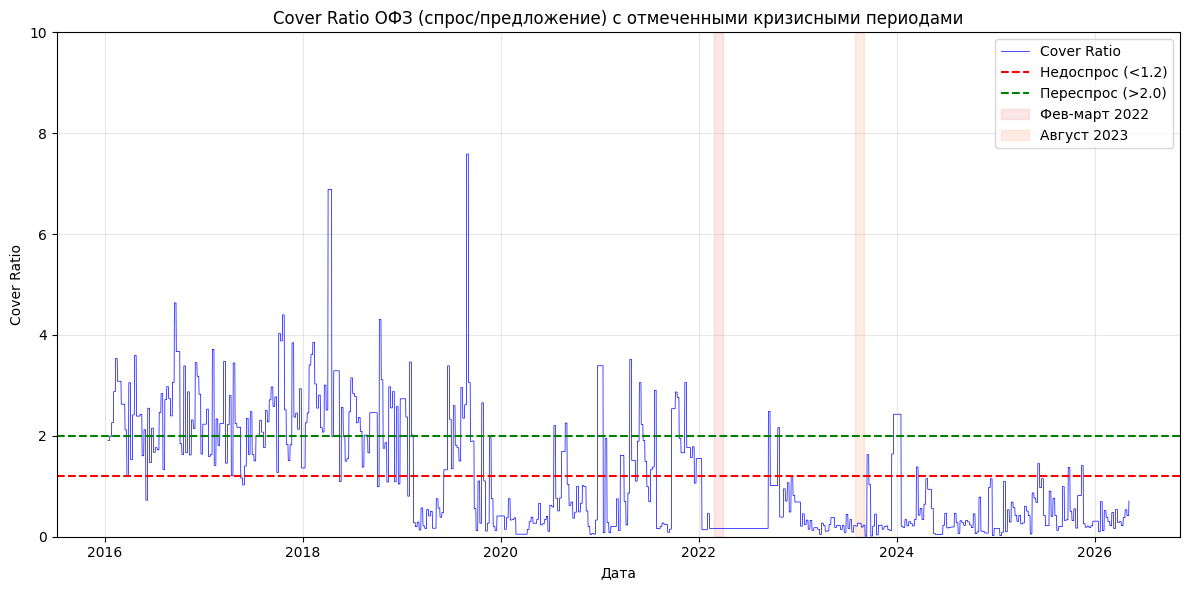

In [22]:
import matplotlib.pyplot as plt

# Оставляем только строки с непустым cover_ratio
df_plot = df_m3_final.dropna(subset=['cover_ratio'])

# Строим график cover_ratio
plt.figure(figsize=(12, 6))
plt.plot(df_plot['date'], df_plot['cover_ratio'], linewidth=0.5, color='blue', label='Cover Ratio')

# Горизонтальные линии
plt.axhline(y=1.2, color='red', linestyle='--', label='Недоспрос (<1.2)')
plt.axhline(y=2.0, color='green', linestyle='--', label='Переспрос (>2.0)')

# Отмечаем кризисные периоды
crisis_zones = [
    ('2022-02-24', '2022-03-31', 'lightcoral', 'Фев-март 2022'),
    ('2023-08-01', '2023-08-31', 'lightsalmon', 'Август 2023'),
]

for start, end, color, label in crisis_zones:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color=color, label=label)

# Оформление
plt.title('Cover Ratio ОФЗ (спрос/предложение) с отмеченными кризисными периодами')
plt.xlabel('Дата')
plt.ylabel('Cover Ratio')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

**Интерпретация: дневной cover ratio и кризисные окна (M3)**

На графике **cover ratio** (отношение спроса к предложению по ОФЗ в агрегированный день) горизонтальные линии 1.2 и 2.0 задают зоны **недоспроса** и **переспроса** относительно принятых порогов. Закрашенные полосы (февраль–март 2022 и август 2023) позволяют визуально сравнить уровень и волатильность покрытия в стрессовые периоды с остальной выборкой: смещение всего ряда вверх или участки с частыми выходами за порог 2.0 указывают на повышенный спрос на бумаги и/или напряжение в размещениях. Ограничение оси Y (например, до 10) обрезает редкие экстремумы ради читаемости основной массы точек.

In [23]:
# Посмотрим распределение MAD-сигналов (должны быть не только нули)
print("=== Статистика MAD-сигналов ===")
print(df_m3_final[['mad_score_cover', 'mad_score_yield', 'mad_score_yield_spread']].describe())

=== Статистика MAD-сигналов ===
       mad_score_cover  mad_score_yield  mad_score_yield_spread
count      3767.000000      3767.000000                  3767.0
mean          0.971153         0.718859                     0.0
std           4.865320         4.022029                     0.0
min          -2.927264       -22.500000                     0.0
25%          -0.017380         0.000000                     0.0
50%           0.000000         0.000000                     0.0
75%           0.041406         0.713457                     0.0
max          44.785793        84.599248                     0.0
